<a href="https://colab.research.google.com/github/Aleem-mja/DeepLearning-Project-SLIIT-SE4050/blob/IT22339324/IT22339324.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# --- Imports ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import nltk, re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [3]:
# --- NLTK setup ---
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
# --- Extract dataset from Drive ---
import tarfile
dataset_path = '/content/drive/MyDrive/aclImdb_v1.tar.gz'
extract_path = '/content/aclImdb'
if not os.path.exists(extract_path):
    with tarfile.open(dataset_path) as tar:
        tar.extractall(path='/content')
print("Dataset extracted.")

/tmp/ipython-input-2368647180.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='/content')


Dataset extracted.


In [5]:
# --- Load IMDB data ---
def load_data_from_folder(folder):
    data = []
    for label in ['pos', 'neg']:
        path = os.path.join(folder, label)
        for file in os.listdir(path):
            with open(os.path.join(path, file), encoding='utf8') as f:
                data.append([f.read(), 1 if label == 'pos' else 0])
    return pd.DataFrame(data, columns=['text', 'label'])

train_data = load_data_from_folder('/content/aclImdb/train')
test_data = load_data_from_folder('/content/aclImdb/test')

In [6]:
# Display a sample of positive reviews (label == 1)
print("Positive reviews sample:")
print(train_data[train_data['label'] == 1].sample(5))  # Display 5 random positive reviews

# Display a sample of negative reviews (label == 0)
print("\nNegative reviews sample:")
print(train_data[train_data['label'] == 0].sample(5))  # Display 5 random negative reviews

Positive reviews sample:
                                                    text  label
6849   As a fan of author John le Carre I've slowly b...      1
12460  A film that is so much a 30's Warners film in ...      1
2829   Lizzie Borden's Love Crimes is an important fi...      1
6856   Let me make one thing clear.for the most part...      1
7629   Lensman is a rather lesser-known Anime gem fro...      1

Negative reviews sample:
                                                    text  label
18509  This is the 2nd time I've seen this movie in a...      0
19025  The animation looks like it was done in 30 sec...      0
14559  I am oh soooo glad I have not spent money to g...      0
21412  Although there are some snippets in this 4-par...      0
20812  Cartoon Network seems to be desperate for rati...      0


### Dataset Details

**Dataset:** IMDB Movie Reviews Dataset (aclImdb)  
**Source:** [IMDB Large Movie Review Dataset by Maas et al.](https://ai.stanford.edu/~amaas/data/sentiment/)  
**Type:** Supervised Sentiment Classification (binary: positive/negative)

**Attributes:**
- Each sample: a movie review (text)  
- Label: 0 = Negative, 1 = Positive  
- Data size: 50,000 reviews total  
  - 25,000 for training  
  - 25,000 for testing  
- Balanced dataset: 50% positive, 50% negative  
- Average review length: ~230 words  

This dataset is widely used in NLP for benchmarking sentiment classification models.  
It provides a real-world example of natural, noisy text, making it suitable for deep learning approaches.



/tmp/ipython-input-3497268499.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=train_data, palette='pastel')


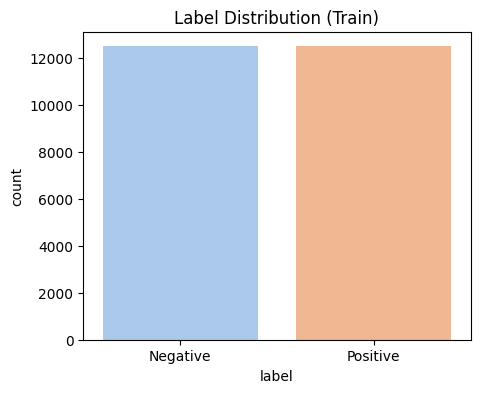

In [7]:
# --- Label distribution plot ---
plt.figure(figsize=(5,4))
sns.countplot(x='label', data=train_data, palette='pastel')
plt.title('Label Distribution (Train)')
plt.xticks([0,1], ['Negative','Positive'])
plt.show()

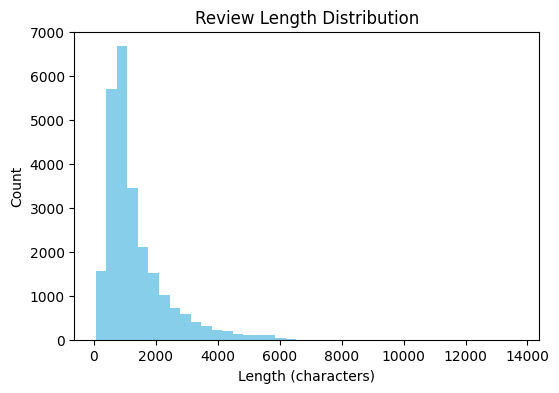

In [8]:
# --- Review length distribution ---
train_data['review_length'] = train_data['text'].apply(len)
plt.figure(figsize=(6,4))
plt.hist(train_data['review_length'], bins=40, color='skyblue')
plt.title('Review Length Distribution')
plt.xlabel('Length (characters)')
plt.ylabel('Count')
plt.show()

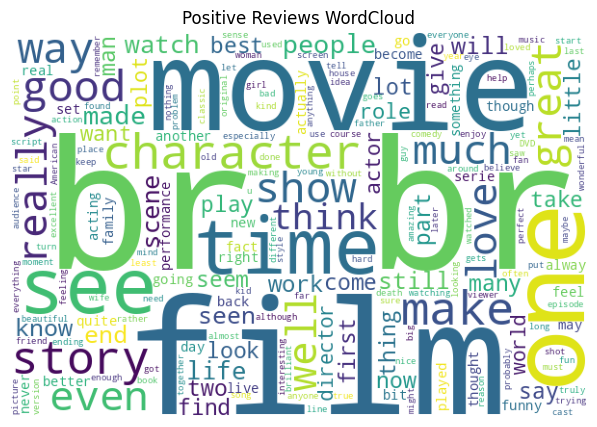

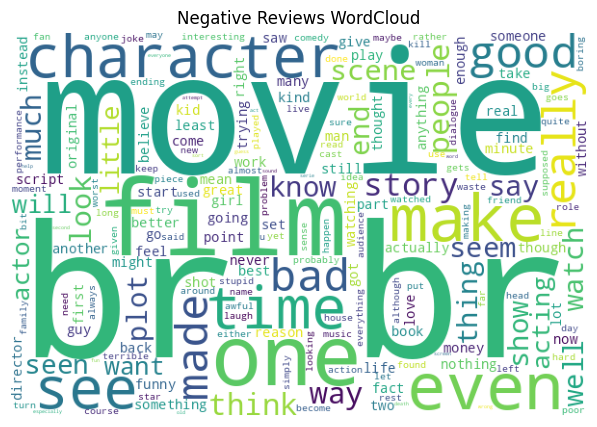

In [9]:
# --- WordClouds ---
pos_text = " ".join(train_data[train_data.label==1]['text'])
neg_text = " ".join(train_data[train_data.label==0]['text'])
wc = WordCloud(width=600, height=400, background_color='white', max_words=200)

plt.figure(figsize=(8,5))
plt.imshow(wc.generate(pos_text))
plt.axis('off')
plt.title("Positive Reviews WordCloud")
plt.show()

plt.figure(figsize=(8,5))
plt.imshow(wc.generate(neg_text))
plt.axis('off')
plt.title("Negative Reviews WordCloud")
plt.show()


In [10]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
# --- Text preprocessing ---
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

train_data['clean_text'] = train_data['text'].apply(preprocess_text)
test_data['clean_text'] = test_data['text'].apply(preprocess_text)

In [12]:
# --- Tokenize and pad sequences ---
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_NB_WORDS = 10000
MAX_SEQUENCE_LENGTH = 200

tokenizer = Tokenizer(num_words=MAX_NB_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train_data['clean_text'])
vocab_size = min(MAX_NB_WORDS, len(tokenizer.word_index)+1)

X_train = pad_sequences(tokenizer.texts_to_sequences(train_data['clean_text']),
                        maxlen=MAX_SEQUENCE_LENGTH, padding='post')
X_test = pad_sequences(tokenizer.texts_to_sequences(test_data['clean_text']),
                       maxlen=MAX_SEQUENCE_LENGTH, padding='post')

y_train = train_data['label'].values
y_test = test_data['label'].values

In [13]:
# --- Load GloVe embeddings ---
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip
embeddings_index = {}
with open("glove.6B.100d.txt", encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs
print(f"Loaded {len(embeddings_index)} word vectors.")

Loaded 400000 word vectors.


In [14]:
# --- Create embedding matrix ---
EMBEDDING_DIM = 100
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec

### Why Bidirectional LSTM (BiLSTM) Was Chosen

Traditional RNNs and LSTMs process text in one direction (left to right).  
However, in natural language, understanding often depends on both past and future context.

**Ex:**  
- “The movie was *not great*.” → The meaning of “not” changes the sentiment of “great.”  

A **Bidirectional LSTM** reads the sequence **forward and backward**, capturing dependencies from both directions.  
This makes it particularly effective for **sentiment analysis**, where context on both sides of a word affects meaning.

**Advantages:**
- Better context understanding  
- Handles long-term dependencies  
- Works well with pre-trained embeddings like GloVe  

Therefore, BiLSTM is chosen over simple LSTM or CNN for improved accuracy in text sentiment classification.


In [20]:
# --- Define the model ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

# Function to create the model
def make_model(vocab_size=10000, embedding_dim=100, input_length=200):
    model = Sequential([
        Embedding(vocab_size, embedding_dim, input_length=input_length),
        Bidirectional(LSTM(128, return_sequences=False)),  # Bidirectional LSTM
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# --- Train/Validation split (faster and simpler) ---
es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

model = make_model(vocab_size=10000, embedding_dim=100, input_length=X_train.shape[1])

history = model.fit(
    X_train, y_train,
    validation_split=0.1,   # 10% for validation
    epochs=5,
    batch_size=64,
    callbacks=[es],
    verbose=1
)


Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 348s 972ms/step - accuracy: 0.7038 - loss: 0.5460 - val_accuracy: 0.7636 - val_loss: 0.5826
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 400s 1s/step - accuracy: 0.9126 - loss: 0.2429 - val_accuracy: 0.8768 - val_loss: 0.3103
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 373s 999ms/step - accuracy: 0.9428 - loss: 0.1706 - val_accuracy: 0.8784 - val_loss: 0.3664
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 344s 978ms/step - accuracy: 0.9590 - loss: 0.1213 - val_accuracy: 0.8324 - val_loss: 0.4944
